# Autoencoder for Image Denoising on MNIST
This notebook builds a simple dense autoencoder to remove noise from MNIST images.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.models import Model

## Load and preprocess data

In [10]:
(x_train,_),(x_test,_) = mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.

noise_factor=0.5
x_train_noisy=np.clip(x_train+noise_factor*np.random.normal(size=x_train.shape),0.,1.)
x_test_noisy=np.clip(x_test+noise_factor*np.random.normal(size=x_test.shape),0.,1.)

x_train_flat=x_train.reshape((-1,784))
x_test_flat=x_test.reshape((-1,784))
x_train_noisy_flat=x_train_noisy.reshape((-1,784))
x_test_noisy_flat=x_test_noisy.reshape((-1,784))

print(x_train.shape,x_test.shape)

(60000, 28, 28) (10000, 28, 28)


## Visualize original and noisy images

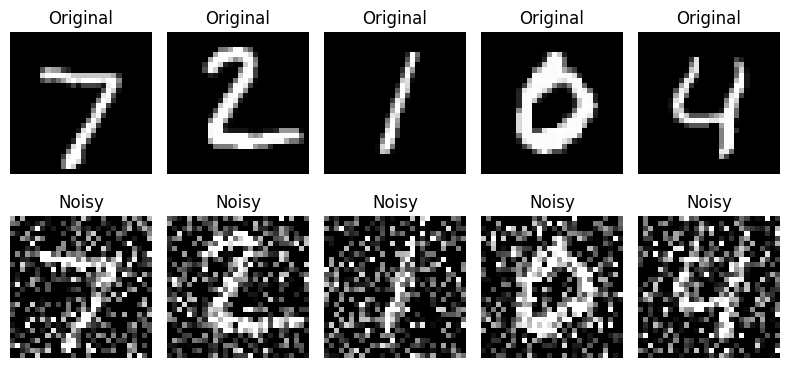

In [11]:
plt.figure(figsize=(8,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i],cmap='gray'); plt.axis('off'); plt.title("Original")
    plt.subplot(2,5,i+6)
    plt.imshow(x_test_noisy[i],cmap='gray'); plt.axis('off'); plt.title("Noisy")
plt.tight_layout(); plt.show()

## Build Autoencoder

In [12]:
inp=Input(shape=(784,))
e=Dense(128,activation='relu')(inp)
e=Dense(64,activation='relu')(e)
e=Dense(32,activation='relu')(e)
d=Dense(64,activation='relu')(e)
d=Dense(128,activation='relu')(d)
out=Dense(784,activation='sigmoid')(d)
autoencoder=Model(inp,out)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [13]:
history=autoencoder.fit(
    x_train_noisy_flat,x_train_flat,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy_flat,x_test_flat)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.2721 - val_loss: 0.2187
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1922 - val_loss: 0.1717
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1665 - val_loss: 0.1600
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1566 - val_loss: 0.1519
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1508 - val_loss: 0.1483
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1470 - val_loss: 0.1443
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1433 - val_loss: 0.1408
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1403 - val_loss: 0.1383
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1380 - val_loss: 0.1364
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1358 - val_loss: 0.1343
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1342 - val_loss: 0.1327
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

## Plot Loss

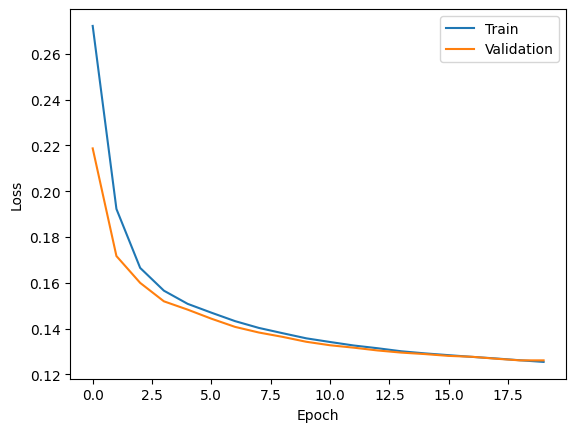

In [14]:
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.show()

## Denoise Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


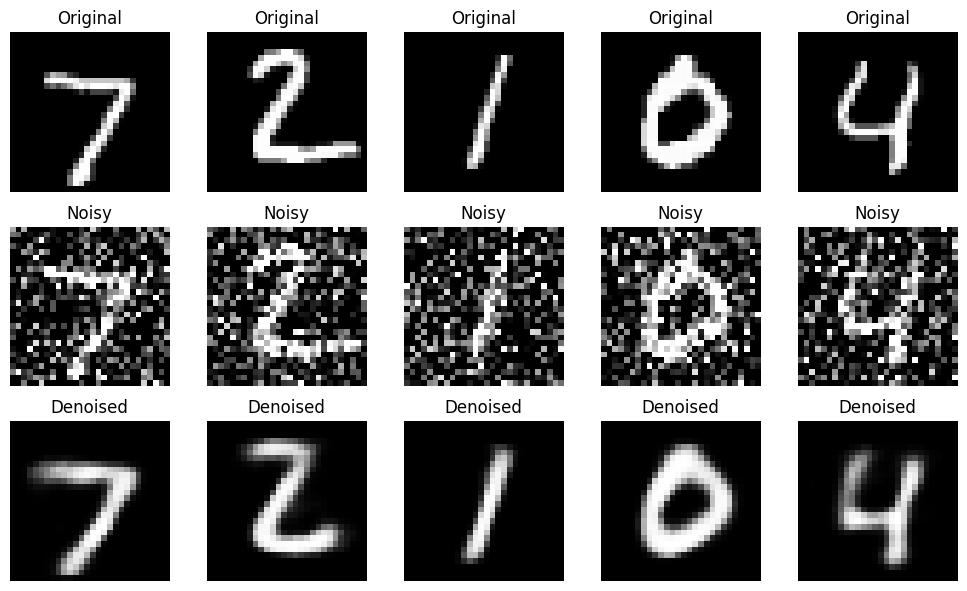

In [15]:
decoded=autoencoder.predict(x_test_noisy_flat)
decoded=decoded.reshape((-1,28,28))

plt.figure(figsize=(10,6))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i],cmap='gray'); plt.axis('off'); plt.title('Original')
    plt.subplot(3,5,i+6)
    plt.imshow(x_test_noisy[i],cmap='gray'); plt.axis('off'); plt.title('Noisy')
    plt.subplot(3,5,i+11)
    plt.imshow(decoded[i],cmap='gray'); plt.axis('off'); plt.title('Denoised')
plt.tight_layout(); plt.show()

## Conclusion
The autoencoder learns to reconstruct clean MNIST digits from noisy inputs. The denoised images should closely resemble the original images after training.